# 01 — Estruturação Dataset NIH ChestX-ray14
**Projeto Integrador SENAI FATESG 2025/2026**  
6 labels em comum | Resize 1024→512 | Target ~5.000/label | Split oficial

## SEÇÃO 0 — Setup e Configurações

In [21]:
# ── Installs ──────────────────────────────────────────────────────────────────
!pip install -q Pillow tqdm pandas numpy

# ── Imports ───────────────────────────────────────────────────────────────────
import os, json, time, random, shutil
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE_DRIVE = '/content/drive/MyDrive'
NIH_DIR    = f'{BASE_DRIVE}/datasets_pi_2026/NIH_CHEST_XRAYS'
CSV_PATH   = f'{NIH_DIR}/Data_Entry_2017.csv'
TRAIN_LIST = f'{NIH_DIR}/train_val_list.txt'
TEST_LIST  = f'{NIH_DIR}/test_list.txt'

OUT_DIR    = f'{BASE_DRIVE}/datasets_pi_2026/estruturacao/NIH'
OUT_TRAIN  = f'{OUT_DIR}/images_512/train'
OUT_TEST   = f'{OUT_DIR}/images_512/test'
OUT_AUG    = f'{OUT_DIR}/images_512/aug'
CKPT_PATH  = f'{OUT_DIR}/ckpt_estruturacao_nih.json'

os.makedirs(OUT_TRAIN, exist_ok=True)
os.makedirs(OUT_TEST,  exist_ok=True)
os.makedirs(OUT_AUG,   exist_ok=True)

# ── Labels canônicas ──────────────────────────────────────────────────────────
LABEL_MAP = {
    'Atelectasis'       : 'atelectasis',
    'Cardiomegaly'      : 'cardiomegaly',
    'Effusion'          : 'pleural_effusion',
    'Pneumothorax'      : 'pneumothorax',
    'Consolidation'     : 'consolidation',
    'Edema'             : 'edema',
    'No Finding'        : 'no_finding',
}
LABELS_6   = ['atelectasis','cardiomegaly','pleural_effusion',
              'pneumothorax','consolidation','edema']
ALL_LABELS = LABELS_6 + ['no_finding']

# ── Targets de balanceamento ──────────────────────────────────────────────────
TARGET = {
    'atelectasis'    : 5000,
    'cardiomegaly'   : 5000,
    'pleural_effusion': 5000,
    'pneumothorax'   : 5000,
    'consolidation'  : 5000,
    'edema'          : 5000,
    'no_finding'     : 15000,
}
# Fator de oversample (originais × fator = target)
OVERSAMPLE_FACTOR = {
    'consolidation' : 1.1,
    'cardiomegaly'  : 1.8,
    'edema'         : 2.2,
}

TARGET_SIZE = (512, 512)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configurações carregadas.')

Configurações carregadas.


## SEÇÃO 1 — Carregamento e Mapeamento do CSV

In [23]:
# ── Lê CSV original ────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH)
print(f'Total de linhas no CSV: {len(df_raw):,}')
print(f'Colunas: {list(df_raw.columns)}')

Total de linhas no CSV: 112,120
Colunas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


In [24]:
# ── Mapeia labels ─────────────────────────────────────────────────────────────
for canon in ALL_LABELS:
    df_raw[canon] = 0

for _, row in df_raw.iterrows():
    findings = [f.strip() for f in str(row['Finding Labels']).split('|')]
    for orig, canon in LABEL_MAP.items():
        if orig in findings:
            df_raw.at[_, canon] = 1

# ── Filtra: mantém apenas imagens com pelo menos 1 dos 6 labels OU no_finding ─
mask = df_raw[ALL_LABELS].sum(axis=1) > 0
df_filtered = df_raw[mask].copy().reset_index(drop=True)
print(f'Imagens após filtro de labels relevantes: {len(df_filtered):,}')

# ── Distribuição por label ─────────────────────────────────────────────────────
print('\nDistribuição por label:')
for lbl in ALL_LABELS:
    n = df_filtered[lbl].sum()
    print(f'  {lbl:<20}: {n:>7,} ({n/len(df_filtered)*100:.2f}%)')

Imagens após filtro de labels relevantes: 91,167

Distribuição por label:
  atelectasis         :  11,559 (12.68%)
  cardiomegaly        :   2,776 (3.04%)
  pleural_effusion    :  13,317 (14.61%)
  pneumothorax        :   5,302 (5.82%)
  consolidation       :   4,667 (5.12%)
  edema               :   2,303 (2.53%)
  no_finding          :  60,361 (66.21%)


## SEÇÃO 2 — Aplicar Split Oficial NIH

In [25]:
# ── Lê listas oficiais ────────────────────────────────────────────────────────
with open(TRAIN_LIST) as f:
    train_files = set(f.read().splitlines())
with open(TEST_LIST) as f:
    test_files = set(f.read().splitlines())

df_filtered['split'] = df_filtered['Image Index'].apply(
    lambda x: 'train' if x in train_files else ('test' if x in test_files else 'unknown')
)

df_train = df_filtered[df_filtered['split'] == 'train'].copy().reset_index(drop=True)
df_test  = df_filtered[df_filtered['split'] == 'test' ].copy().reset_index(drop=True)

print(f'Train: {len(df_train):,} imagens')
print(f'Test : {len(df_test):,} imagens')
print(f'Unknown: {(df_filtered["split"]=="unknown").sum():,} imagens')

Train: 70,681 imagens
Test : 20,486 imagens
Unknown: 0 imagens


## SEÇÃO 3 — Estratégia de Balanceamento (Train)

In [26]:
# ── Para cada label, seleciona índices que serão usados ──────────────────────
random.seed(RANDOM_SEED)

# Undersample: Atelectasis, Pleural Effusion, No Finding
# Keep: Pneumothorax
# Oversample: Consolidation, Cardiomegaly, Edema

selected_idx = set()
oversample_jobs = []  # (img_index, label, n_copies)

for lbl in ALL_LABELS:
    positives = df_train[df_train[lbl] == 1].index.tolist()
    target = TARGET[lbl]

    if len(positives) <= target:
        # Undersample não necessário — adiciona todos
        selected_idx.update(positives)
        # Verifica se precisa de oversample
        if lbl in OVERSAMPLE_FACTOR:
            n_copies = int(round(target / len(positives))) - 1
            for idx in positives:
                oversample_jobs.append((idx, lbl, n_copies))
    else:
        # Undersample
        sampled = random.sample(positives, target)
        selected_idx.update(sampled)

df_balanced = df_train.loc[sorted(selected_idx)].copy().reset_index(drop=True)
print(f'Imagens originais selecionadas para treino: {len(df_balanced):,}')
print('\nDistribuição pós-balanceamento (originais):')
for lbl in ALL_LABELS:
    n = df_balanced[lbl].sum()
    print(f'  {lbl:<20}: {n:>6,}')
print(f'\nJobs de oversample: {len(oversample_jobs):,} cópias a gerar')

Imagens originais selecionadas para treino: 30,686

Distribuição pós-balanceamento (originais):
  atelectasis         :  5,875
  cardiomegaly        :  1,707
  pleural_effusion    :  6,287
  pneumothorax        :  2,637
  consolidation       :  2,852
  edema               :  1,378
  no_finding          : 15,000

Jobs de oversample: 5,937 cópias a gerar


## SEÇÃO 4 — Funções de Processamento e Augmentation

In [27]:
from PIL import Image, ImageEnhance
import random

def resize_nih(img_path, out_path, size=(512,512)):
    """Resize direto 1024→512, salva PNG."""
    with Image.open(img_path) as img:
        img = img.convert('L')          # grayscale
        img = img.resize(size, Image.LANCZOS)
        img.save(out_path, format='PNG')

def augment_nih(img_path, out_path, seed=None):
    """Augmentation clínico seguro: flip H, rotação ±5°, brilho ±10%."""
    if seed is not None:
        random.seed(seed)
    with Image.open(img_path) as img:
        img = img.convert('L')
        img = img.resize((512,512), Image.LANCZOS)
        # Flip horizontal
        if random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        # Rotação ±5°
        angle = random.uniform(-5, 5)
        img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
        # Brilho ±10%
        factor = random.uniform(0.90, 1.10)
        img = ImageEnhance.Brightness(img).enhance(factor)
        img.save(out_path, format='PNG')

def find_image(img_name, nih_dir):
    """Localiza imagem nas subpastas do NIH."""
    for root, _, files in os.walk(nih_dir):
        if img_name in files:
            return os.path.join(root, img_name)
    return None

print('Funções definidas.')

Funções definidas.


## SEÇÃO 5 — Processamento das Imagens (com Checkpoint)

In [28]:
# ── Carrega checkpoint se existir ─────────────────────────────────────────────
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        ckpt = json.load(f)
    done_originals = set(ckpt.get('done_originals', []))
    done_aug       = set(ckpt.get('done_aug', []))
    print(f'Checkpoint encontrado: {len(done_originals):,} originais + {len(done_aug):,} aug concluídos')
else:
    done_originals = set()
    done_aug       = set()
    print('Sem checkpoint — iniciando do zero.')

errors = []

Checkpoint encontrado: 30,686 originais + 10,140 aug concluídos


In [29]:
# ── Processa imagens originais (train balanceado) ─────────────────────────────
rows_train = []
t0 = time.time()

for i, row in tqdm(df_balanced.iterrows(), total=len(df_balanced), desc='Train originals'):
    img_name = row['Image Index']
    if img_name in done_originals:
        # Já processado — reconstrói row do CSV
        out_path = os.path.join(OUT_TRAIN, img_name.replace('.png','') + '.png')
        rows_train.append({
            'img_path': out_path, **{lbl: int(row[lbl]) for lbl in ALL_LABELS},
            'peso_sample': 0.0, 'aug_copy': 0
        })
        continue

    src = find_image(img_name, NIH_DIR)
    if src is None:
        errors.append(img_name)
        continue

    out_name = img_name.replace('.png','').replace('.jpg','') + '.png'
    out_path = os.path.join(OUT_TRAIN, out_name)

    try:
        resize_nih(src, out_path)
        done_originals.add(img_name)
        rows_train.append({
            'img_path': out_path, **{lbl: int(row[lbl]) for lbl in ALL_LABELS},
            'peso_sample': 0.0, 'aug_copy': 0
        })
    except Exception as e:
        errors.append(f'{img_name}: {e}')

    # Checkpoint a cada 500
    if len(done_originals) % 500 == 0:
        with open(CKPT_PATH, 'w') as f:
            json.dump({'done_originals': list(done_originals),
                       'done_aug': list(done_aug)}, f)

print(f'\nOriginais train: {len(rows_train):,} | Erros: {len(errors):,} | Tempo: {time.time()-t0:.0f}s')

Train originals: 100%|██████████| 30686/30686 [00:01<00:00, 22477.44it/s]


Originais train: 30,686 | Erros: 0 | Tempo: 1s


In [30]:
# ── Pre-indexa imagens NIH uma única vez ──────────────────────────────────────
print('Indexando imagens NIH...')
img_index = {}
for root, _, files in os.walk(NIH_DIR):
    for fname in files:
        if fname.endswith('.png') or fname.endswith('.jpg'):
            img_index[fname] = os.path.join(root, fname)
print(f'Total indexado: {len(img_index):,} imagens')

# ── Gera cópias de augmentation ──────────────────────────────────────────────
rows_aug = []

for (idx, lbl, n_copies) in tqdm(oversample_jobs, desc='Augmentation'):
    row = df_train.loc[idx]
    img_name = row['Image Index']
    src = img_index.get(img_name)          # ← substituído
    if src is None:
        continue

    for copy_n in range(1, n_copies + 1):
        aug_key = f'{img_name}_aug{copy_n}'
        out_name = img_name.replace('.png','').replace('.jpg','') + f'_aug{copy_n}.png'
        out_path = os.path.join(OUT_AUG, out_name)

        if aug_key in done_aug:
            rows_aug.append({
                'img_path': out_path, **{l: int(row[l]) for l in ALL_LABELS},
                'peso_sample': 0.0, 'aug_copy': copy_n
            })
            continue
        try:
            augment_nih(src, out_path, seed=idx * 100 + copy_n)
            done_aug.add(aug_key)
            rows_aug.append({
                'img_path': out_path, **{l: int(row[l]) for l in ALL_LABELS},
                'peso_sample': 0.0, 'aug_copy': copy_n
            })
        except Exception as e:
            errors.append(f'{aug_key}: {e}')

    if len(done_aug) % 200 == 0:
        with open(CKPT_PATH, 'w') as f:
            json.dump({'done_originals': list(done_originals),
                       'done_aug': list(done_aug)}, f)

print(f'Cópias aug geradas: {len(rows_aug):,} | Erros acumulados: {len(errors):,}')

Indexando imagens NIH...
Total indexado: 112,120 imagens


Augmentation: 100%|██████████| 5937/5937 [00:00<00:00, 14062.92it/s]

Cópias aug geradas: 10,400 | Erros acumulados: 0


In [31]:
# ── Processa imagens de teste ──────────────────────────────────────────────────
rows_test = []

for i, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Test'):
    img_name = row['Image Index']
    src = img_index.get(img_name)          # ← substituído
    if src is None:
        errors.append(img_name)
        continue
    out_name = img_name.replace('.png','').replace('.jpg','') + '.png'
    out_path = os.path.join(OUT_TEST, out_name)
    try:
        resize_nih(src, out_path)
        rows_test.append({
            'img_path': out_path, **{lbl: int(row[lbl]) for lbl in ALL_LABELS},
            'peso_sample': 0.0, 'aug_copy': 0
        })
    except Exception as e:
        errors.append(f'{img_name}: {e}')

print(f'Test: {len(rows_test):,} imagens | Erros: {len(errors):,}')

Test: 100%|██████████| 20486/20486 [28:50<00:00, 11.84it/s]

Test: 20,486 imagens | Erros: 0


## SEÇÃO 6 — Cálculo de Pesos e Geração dos CSVs

In [32]:
# ── Monta DataFrame final train ───────────────────────────────────────────────
df_out_train = pd.DataFrame(rows_train + rows_aug)
N = len(df_out_train)

# ── Calcula peso por sample ───────────────────────────────────────────────────
# w_k = N / (n_classes * N_k) para cada label k
# peso_sample = média dos w_k dos labels positivos da imagem
n_classes = len(ALL_LABELS)
label_weights = {}
for lbl in ALL_LABELS:
    n_pos = df_out_train[lbl].sum()
    label_weights[lbl] = N / (n_classes * n_pos) if n_pos > 0 else 1.0

def compute_weight(row):
    pos_labels = [lbl for lbl in ALL_LABELS if row[lbl] == 1]
    if not pos_labels:
        return 1.0
    return float(np.mean([label_weights[lbl] for lbl in pos_labels]))

df_out_train['peso_sample'] = df_out_train.apply(compute_weight, axis=1)

print(f'Train final: {len(df_out_train):,} imagens (originais + aug)')
print('\nDistribuição final por label:')
for lbl in ALL_LABELS:
    n = df_out_train[lbl].sum()
    print(f'  {lbl:<20}: {n:>6,} ({n/len(df_out_train)*100:.1f}%)')
print('\nLabel weights (Focal Loss):')
for lbl, w in label_weights.items():
    print(f'  {lbl:<20}: {w:.4f}')

Train final: 41,086 imagens (originais + aug)

Distribuição final por label:
  atelectasis         :  7,449 (18.1%)
  cardiomegaly        :  5,350 (13.0%)
  pleural_effusion    :  9,311 (22.7%)
  pneumothorax        :  2,827 (6.9%)
  consolidation       :  6,111 (14.9%)
  edema               :  5,715 (13.9%)
  no_finding          : 15,000 (36.5%)

Label weights (Focal Loss):
  atelectasis         : 0.7879
  cardiomegaly        : 1.0971
  pleural_effusion    : 0.6304
  pneumothorax        : 2.0762
  consolidation       : 0.9605
  edema               : 1.0270
  no_finding          : 0.3913


In [33]:
# ── Salva CSVs ────────────────────────────────────────────────────────────────
df_out_test = pd.DataFrame(rows_test)
N_test = len(df_out_test)
for lbl in ALL_LABELS:
    n_pos = df_out_test[lbl].sum()
    df_out_test['peso_sample'] = df_out_test.apply(compute_weight, axis=1)

csv_train_path = f'{OUT_DIR}/nih_train_7labels.csv'
csv_test_path  = f'{OUT_DIR}/nih_test_7labels.csv'

cols = ['img_path'] + ALL_LABELS + ['peso_sample', 'aug_copy']
df_out_train[cols].to_csv(csv_train_path, index=False)
df_out_test[cols].to_csv(csv_test_path,   index=False)

print(f'CSVs salvos:')
print(f'  {csv_train_path}  ({len(df_out_train):,} linhas)')
print(f'  {csv_test_path}   ({len(df_out_test):,} linhas)')
print(f'\nErros totais: {len(errors):,}')
if errors:
    print('Primeiros 10 erros:', errors[:10])

# Checkpoint final
with open(CKPT_PATH, 'w') as f:
    json.dump({'done_originals': list(done_originals),
               'done_aug': list(done_aug), 'completed': True}, f)
print('\n Estruturação NIH concluída.')

CSVs salvos:
  /content/drive/MyDrive/datasets_pi_2026/estruturacao/NIH/nih_train_7labels.csv  (41,086 linhas)
  /content/drive/MyDrive/datasets_pi_2026/estruturacao/NIH/nih_test_7labels.csv   (20,486 linhas)

Erros totais: 0

 Estruturação NIH concluída.


## SEÇÃO 7 — Visualização do Dataset Final


SEÇÃO 7 — Visualização do Dataset Final Balanceado


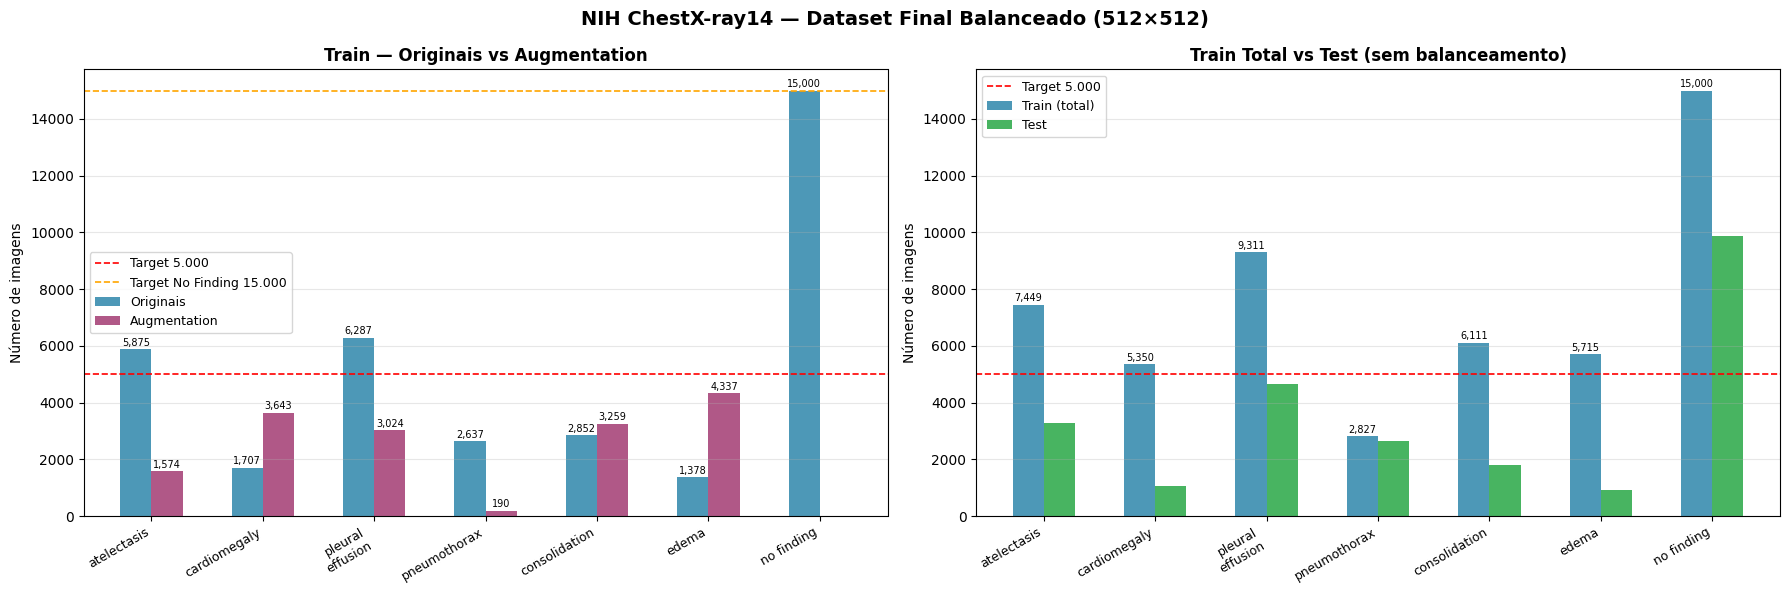


Gráfico salvo: /content/drive/MyDrive/datasets_pi_2026/estruturacao/NIH/dataset_balance_final.png

Label                  Train orig    Train aug  Train total     Test
----------------------------------------------------------------------
atelectasis                 5,875        1,574        7,449    3,279
cardiomegaly                1,707        3,643        5,350    1,069
pleural_effusion            6,287        3,024        9,311    4,658
pneumothorax                2,637          190        2,827    2,665
consolidation               2,852        3,259        6,111    1,815
edema                       1,378        4,337        5,715      925
no_finding                 15,000            0       15,000    9,861
----------------------------------------------------------------------
TOTAL                      35,736       16,027       51,763   24,272


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

section = lambda t: print(f'\n{"="*65}\n{t}\n{"="*65}')
section('SEÇÃO 7 — Visualização do Dataset Final Balanceado')

# ── Recarrega CSVs se necessário ──────────────────────────────────────────────
if 'df_out_train' not in dir():
    df_out_train = pd.read_csv(f'{OUT_DIR}/nih_train_7labels.csv')
    df_out_test  = pd.read_csv(f'{OUT_DIR}/nih_test_7labels.csv')
    print('CSVs recarregados.')

# ── Dados para o gráfico ──────────────────────────────────────────────────────
labels_plot = ALL_LABELS
train_orig  = [df_out_train[df_out_train['aug_copy']==0][lbl].sum() for lbl in labels_plot]
train_aug   = [df_out_train[df_out_train['aug_copy']>0][lbl].sum()  for lbl in labels_plot]
test_counts = [df_out_test[lbl].sum() for lbl in labels_plot]

x = np.arange(len(labels_plot))
w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('NIH ChestX-ray14 — Dataset Final Balanceado (512×512)',
             fontsize=14, fontweight='bold')

# ── Plot 1: Train — originais vs aug ─────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - w/2, train_orig, w, label='Originais', color='#2E86AB', alpha=0.85)
bars2 = ax.bar(x + w/2, train_aug,  w, label='Augmentation', color='#A23B72', alpha=0.85)
ax.axhline(y=5000, color='red', linestyle='--', linewidth=1.2, label='Target 5.000')
ax.axhline(y=15000, color='orange', linestyle='--', linewidth=1.2, label='Target No Finding 15.000')
ax.set_xticks(x)
ax.set_xticklabels([l.replace('_',' ').replace('pleural effusion','pleural\neffusion')
                    for l in labels_plot], rotation=30, ha='right', fontsize=9)
ax.set_title('Train — Originais vs Augmentation', fontweight='bold')
ax.set_ylabel('Número de imagens')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)

# ── Plot 2: Train total vs Test ───────────────────────────────────────────────
ax2 = axes[1]
train_total = [o + a for o, a in zip(train_orig, train_aug)]
bars3 = ax2.bar(x - w/2, train_total, w, label='Train (total)', color='#2E86AB', alpha=0.85)
bars4 = ax2.bar(x + w/2, test_counts, w, label='Test',          color='#28A745', alpha=0.85)
ax2.axhline(y=5000, color='red', linestyle='--', linewidth=1.2, label='Target 5.000')
ax2.set_xticks(x)
ax2.set_xticklabels([l.replace('_',' ').replace('pleural effusion','pleural\neffusion')
                     for l in labels_plot], rotation=30, ha='right', fontsize=9)
ax2.set_title('Train Total vs Test (sem balanceamento)', fontweight='bold')
ax2.set_ylabel('Número de imagens')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/dataset_balance_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nGráfico salvo: {OUT_DIR}/dataset_balance_final.png')

# ── Tabela resumo ──────────────────────────────────────────────────────────────
print(f'\n{"Label":<20} {"Train orig":>12} {"Train aug":>12} {"Train total":>12} {"Test":>8}')
print('-' * 70)
for i, lbl in enumerate(labels_plot):
    print(f'{lbl:<20} {train_orig[i]:>12,} {train_aug[i]:>12,} {train_total[i]:>12,} {test_counts[i]:>8,}')
print('-' * 70)
print(f'{"TOTAL":<20} {sum(train_orig):>12,} {sum(train_aug):>12,} {sum(train_total):>12,} {sum(test_counts):>8,}')

In [35]:
# Verifica se as imagens de test estão no índice
sample_test = df_test['Image Index'].head(5).tolist()
for img in sample_test:
    print(f'{img} → {img_index.get(img)}')

00000013_000.png → /content/drive/MyDrive/datasets_pi_2026/NIH_CHEST_XRAYS/images_001/images/00000013_000.png
00000013_001.png → /content/drive/MyDrive/datasets_pi_2026/NIH_CHEST_XRAYS/images_001/images/00000013_001.png
00000013_002.png → /content/drive/MyDrive/datasets_pi_2026/NIH_CHEST_XRAYS/images_001/images/00000013_002.png
00000013_004.png → /content/drive/MyDrive/datasets_pi_2026/NIH_CHEST_XRAYS/images_001/images/00000013_004.png
00000013_005.png → /content/drive/MyDrive/datasets_pi_2026/NIH_CHEST_XRAYS/images_001/images/00000013_005.png
